/opt/miniconda3/envs/NQS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/NQS/lib/python3.10/site-packages/netket/graph/common_lattices.py:126: InitializePeriodicLatticeOnSmallLatticeWarning: 
You are attempting to define a lattice with length 2 in dimension 0 using periodic boundary condition.

Lattice with less than two sites in one direction does not support periodic boundary condition.
The behavior of the lattice is equivalent to an open boundary condition in this direction.

To avoid this warning, consider either using a lattice with more than two sites in the direction you want to be periodic,
or define the graph using :class:`~netket.graph.Graph` by adding the edges manually.


-------------------------------------------------------
For more detailed informations, visit the fo

Hamiltonian = -1.0 [6^ 7] +
-1.0 [7^ 6] +
-1.0 [4^ 6] +
-1.0 [6^ 4] +
-1.0 [5^ 7] +
-1.0 [7^ 5] +
-1.0 [4^ 5] +
-1.0 [5^ 4] +
-1.0 [2^ 3] +
-1.0 [3^ 2] +
-1.0 [0^ 2] +
-1.0 [2^ 0] +
-1.0 [1^ 3] +
-1.0 [3^ 1] +
-1.0 [0^ 1] +
-1.0 [1^ 0] +
0.01 [4^ 4 0^ 0] +
0.01 [5^ 5 1^ 1] +
0.01 [6^ 6 2^ 2] +
0.01 [7^ 7 3^ 3]


100%|██████████| 500/500 [00:20<00:00, 23.84it/s, Energy=-3.9887+0.0002j ± 0.0015 [σ²=0.0011, R̂=1.0164]]


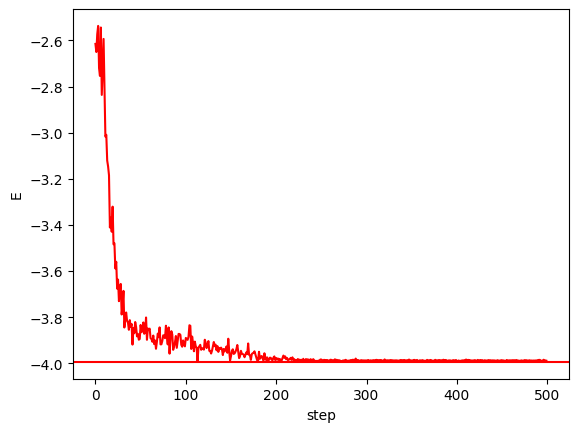

In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json


L = 2  # take a 2x2 lattice
D = 2
t = 1  # tunneling/hopping
U = 0.01  # coulomb

# create the graph our fermions can hop on
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=True)
n_sites = g.n_nodes

# create a hilbert space with 2 up and 2 down spins
hi = nk.hilbert.SpinOrbitalFermions(n_sites, s=1 / 2, n_fermions_per_spin=(2, 2))


# create an operator representing fermi hubbard interactions
# -t (i^ j + h.c.) + U (i^ i j^ j)
# we will create a helper function to abbreviate the creation, destruction and number operators
# each operator has a site and spin projection (sz) in order to find the right position in the hilbert space samples
def c(site, sz):
    return nk.operator.fermion.destroy(hi, site, sz=sz)


def cdag(site, sz):
    return nk.operator.fermion.create(hi, site, sz=sz)


def nc(site, sz):
    return nk.operator.fermion.number(hi, site, sz=sz)


up = +1
down = -1
ham = 0.0
for sz in (up, down):
    for u, v in g.edges():
        ham += -t * cdag(u, sz) * c(v, sz) - t * cdag(v, sz) * c(u, sz)
for u in g.nodes():
    ham += U * nc(u, up) * nc(u, down)

print("Hamiltonian =", ham.operator_string())

# metropolis exchange moves fermions around according to a graph
# the physical graph has LxL vertices, but the computational basis defined by the
# hilbert space contains (2s+1)*L*L occupation numbers
# by taking a disjoint copy of the lattice, we can
# move the fermions around independently for both spins
# and therefore conserve the number of fermions with up and down spin

# we can do this explicitly
# g.n_nodes == L*L --> disj_graph == 2*L*L
disj_graph = nk.graph.disjoint_union(g, g)
sa = nk.sampler.MetropolisFermionHop(hi, graph=g, n_chains=16, sweep_size=64)
# or let netket copy the graph per spin sector
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, sweep_size=64, spin_symmetric=True
)

# since the hilbert basis is a set of occupation numbers, we can take a general RBM
# we take complex parameters, since it learns sign structures more easily, and for even fermion number, the wave function might be complex
ma = nk.models.RBM(alpha=1, param_dtype=complex, use_visible_bias=False)

vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=10, n_samples=512)

# we will use sgd with Stochastic Reconfiguration
opt = nk.optimizer.Sgd(learning_rate=0.01)
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)

gs = nk.driver.VMC(ham, opt, variational_state=vs, preconditioner=sr)

# now run the optimization
# first step will take longer in order to compile
exp_name = "fermions_test"
gs.run(500, out=exp_name)

############## plot #################

ed_energies = np.linalg.eigvalsh(ham.to_dense())

with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]["real"]

# plot the energy levels
plt.axhline(ed_energies[0], color="red", label="E0")
# for e in ed_energies[1:]:
#     plt.axhline(e, color="black")
plt.plot(x, y, color="red", label="VMC")
plt.xlabel("step")
plt.ylabel("E")
plt.show()

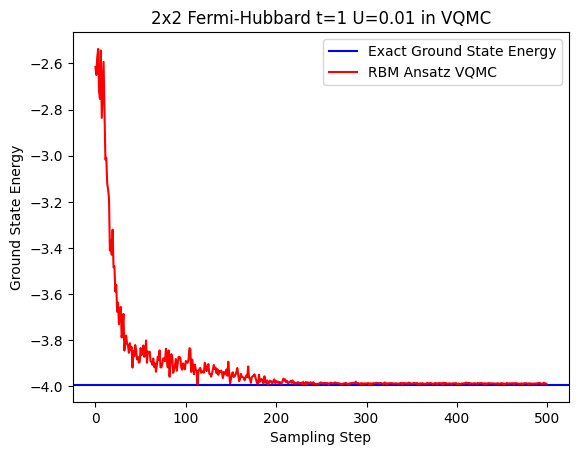

In [2]:
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]["real"]

# plot the energy levels
plt.axhline(ed_energies[0], color="blue", label="Exact Ground State Energy")
# for e in ed_energies[1:]:
#     plt.axhline(e, color="black")
plt.plot(x, y, color="red", label="RBM Ansatz VQMC")
plt.legend()
plt.title("2x2 Fermi-Hubbard t=1 U=0.01 in VQMC")
plt.xlabel("Sampling Step")
plt.ylabel("Ground State Energy")
plt.show()